<a href="https://colab.research.google.com/github/alvesgp/420_Project/blob/main/BNFO_CAPSTONE_R.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
if (!requireNamespace("BiocManager", quietly = TRUE))
  install.packages("BiocManager")


BiocManager::install(c("DESeq2", "readxl", "tidyverse", "ggplot2", "clusterProfiler", "org.Hs.eg.db"), force = TRUE)


library(DESeq2)
library(readxl)
library(tidyverse)
library(ggplot2)
library(clusterProfiler)
library(org.Hs.eg.db)
library(AnnotationDbi)
library(ggrepel)

install.packages("pheatmap", dependencies = TRUE)
library(pheatmap)

'getOption("repos")' replaces Bioconductor standard repositories, see
'help("repositories", package = "BiocManager")' for details.
Replacement repositories:
    CRAN: https://cran.rstudio.com

Bioconductor version 3.22 (BiocManager 1.30.27), R 4.5.3 (2026-03-11)

Installing package(s) 'DESeq2', 'readxl', 'tidyverse', 'ggplot2',
  'clusterProfiler', 'org.Hs.eg.db'

Old packages: 'backports', 'bit64', 'cli', 'cpp11', 'curl', 'devtools',
  'dplyr', 'ellipsis', 'fs', 'ggplot2', 'glue', 'magrittr', 'nlme', 'openssl',
  'pak', 'pkgload', 'processx', 'ps', 'purrr', 'Rcpp', 'rlang', 'S7', 'vctrs',
  'xtable'

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [ ]:
# Read in Metadata
meta_data <- read_excel("meta data.xlsx")

head(meta_data)
colnames(meta_data)

#Read in Raw Counts Data
raw_counts <- read.delim("GSE135251_raw_counts_GRCh38.p13_NCBI.tsv.gz")

rownames(raw_counts) <- raw_counts[,1]
counts <- raw_counts[, -1]

head(counts)
dim(counts)


Group,Accession,Title,Source name,Nas score,Fibrosis stage,Group in paper,Disease,Stage
<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<chr>,<chr>,<chr>
-,GSM3998171,Liver patient 105,NAFLD_early_liver biopsy,5,0,NASH_F0-F1,NAFLD,early
-,GSM3998175,Liver patient 112,NAFLD_early_liver biopsy,2,0,NAFL,NAFLD,early
-,GSM3998189,Liver patient 15,NAFLD_early_liver biopsy,5,0,NAFL,NAFLD,early
-,GSM3998202,Liver patient 169,NAFLD_early_liver biopsy,5,0,NAFL,NAFLD,early
-,GSM3998206,Liver patient 173,NAFLD_early_liver biopsy,6,0,NASH_F0-F1,NAFLD,early
-,GSM3998213,Liver patient 195,NAFLD_early_liver biopsy,4,0,NAFL,NAFLD,early


[1] "Group"          "Accession"      "Title"          "Source name"   
[5] "Nas score"      "Fibrosis stage" "Group in paper" "Disease"       
[9] "Stage"

,GSM3998167,GSM3998168,GSM3998169,GSM3998170,GSM3998171,GSM3998172,GSM3998173,GSM3998174,GSM3998175,GSM3998176,⋯,GSM3998373,GSM3998374,GSM3998375,GSM3998376,GSM3998377,GSM3998378,GSM3998379,GSM3998380,GSM3998381,GSM3998382
,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,⋯,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
100287102,3,0,1,2,3,0,1,1,0,1,⋯,7,8,6,4,5,5,18,3,2,3
653635,165,133,140,216,263,119,336,184,88,100,⋯,436,304,297,282,220,303,374,277,325,468
102466751,5,5,3,11,9,8,12,7,2,2,⋯,22,10,5,5,11,8,10,8,6,15
107985730,0,0,0,1,0,1,1,0,0,0,⋯,1,0,0,2,1,1,0,1,0,1
100302278,0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
645520,0,0,0,1,0,0,4,0,0,0,⋯,0,0,2,0,0,0,0,0,1,1


[1] 39376   216

In [ ]:
# Match Metadata and Raw Counts
meta_data <- meta_data[match(colnames(counts), meta_data$Accession), ]

all(colnames(counts) == meta_data$Accession)

unique(meta_data$Stage)

[1] TRUE

[1] "early"    "moderate" "control"

In [ ]:

# Create DESeq2 dataset
DESeq_dataset <- DESeqDataSetFromMatrix(countData = counts, colData = meta_data, design =~ Stage)

# Run DESeq2
DESeq_dataset <- DESeq_dataset[rowSums(counts(DESeq_dataset)) > 10, ]
DESeq_dataset <- DESeq(DESeq_dataset)

DESeq_results <- results(DESeq_dataset, contrast = c("Stage", "moderate", "early"))

summary(DESeq_results)

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates

fitting model and testing

-- replacing outliers and refitting for 286 genes
-- DESeq argument 'minReplicatesForReplace' = 7 
-- original counts are preserved in counts(dds)

estimating dispersions

fitting model and testing




out of 30918 with nonzero total read count
adjusted p-value < 0.1
LFC > 0 (up)       : 4821, 16%
LFC < 0 (down)     : 2940, 9.5%
outliers [1]       : 0, 0%
low counts [2]     : 4200, 14%
(mean count < 0)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results



In [ ]:

results_df <- as.data.frame(DESeq_results)
results_df$ENTREZID <- rownames(results_df)

# Remove NA
results_df <- results_df[!is.na(results_df$padj), ]

# Define significance
results_df$Significance <- "Not Significant"
results_df$Significance[results_df$padj < 0.05 & results_df$log2FoldChange > 1] <- "Upregulated"
results_df$Significance[results_df$padj < 0.05 & results_df$log2FoldChange < -1] <- "Downregulated"

# Significant genes
sig_genes <- results_df[results_df$padj < 0.05, ]
sig_genes <- sig_genes[order(sig_genes$padj), ]

write.csv(sig_genes, "DESeq2_sig_genes.csv")

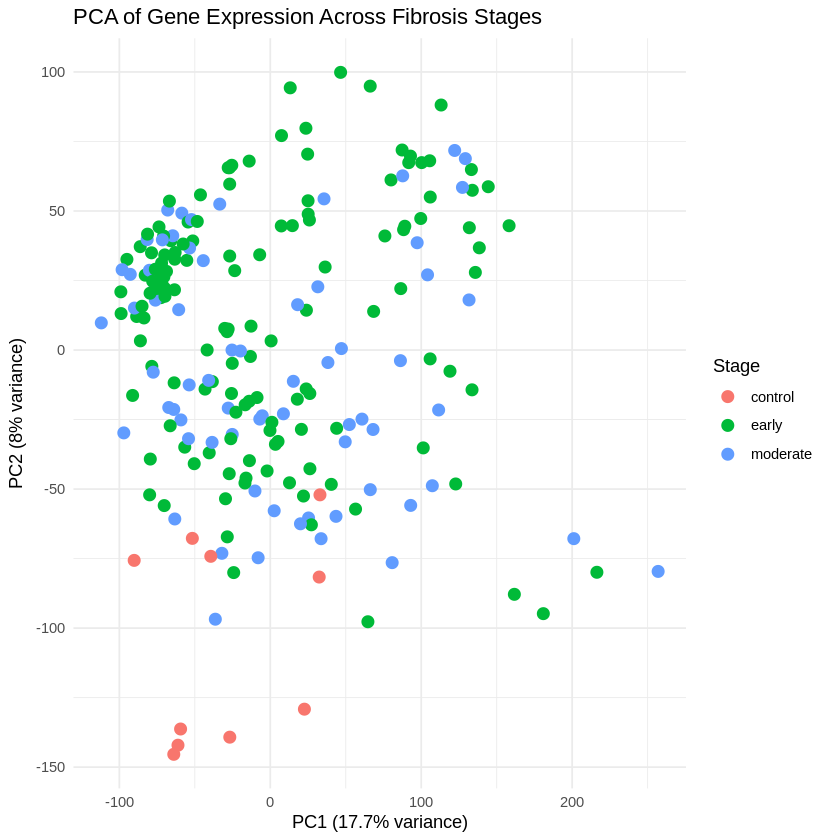

In [ ]:
## PCA ANALYSIS

# Variance stabilizing transformation
PCA_fig <- vst(DESeq_dataset, blind = FALSE)

# Extract normalized expression matrix
vsd_matrix <- assay(PCA_fig)

# Rows = samples, columns = genes
vsd_matrix <- t(vsd_matrix)

# Run PCA
pca_results <- prcomp(vsd_matrix, scale = TRUE)

# Calculate variance explained
pca_variance <- pca_results$sdev^2
percent_var <- round(pca_variance / sum(pca_variance) * 100, 1)

# Create dataframe for plotting
pca_df <- data.frame(
  PC1 = pca_results$x[,1],
  PC2 = pca_results$x[,2],
  Stage = meta_data$Stage
)

# PCA plot
ggplot(pca_df, aes(x = PC1, y = PC2, color = Stage)) +
  geom_point(size = 3) +
  theme_minimal() +
  labs(
    title = "PCA of Gene Expression Across Fibrosis Stages",
    x = paste0("PC1 (", percent_var[1], "% variance)"),
    y = paste0("PC2 (", percent_var[2], "% variance)")
  )

'select()' returned 1:1 mapping between keys and columns



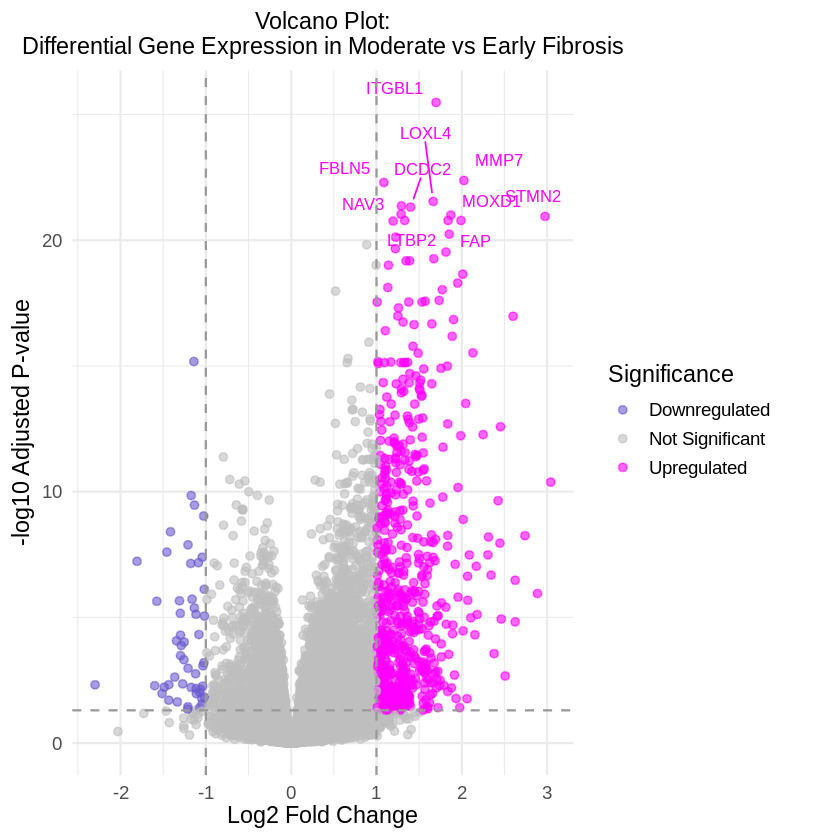

In [ ]:
## Volcano Plot

# create top genes
top10_genes <- results_df[order(results_df$padj), ][1:10, ]

# assign IDs
top10_genes$ENTREZID <- rownames(top10_genes)

# Map IDs to gene symbols
annotations <- select(org.Hs.eg.db, keys = top10_genes$ENTREZID, columns = "SYMBOL", keytype = "ENTREZID" )

# Merge annotations into top10 genes
top10_genes$SYMBOL <- annotations$SYMBOL[match(top10_genes$ENTREZID, annotations$ENTREZID)]

# Volcano plot
ggplot(results_df, aes(x = log2FoldChange, y = -log10(padj), color = Significance)) +
  geom_point(alpha = 0.6) +

  geom_text_repel(
    data = top10_genes,
    aes(label = SYMBOL),
    size = 3.5,
    box.padding = 0.5,
    point.padding = 0.3,
    max.overlaps = Inf,
    show.legend = FALSE
  ) +

  geom_vline(xintercept = c(-1, 1), linetype = "dashed", color = "gray60") +
  geom_hline(yintercept = -log10(0.05), linetype = "dashed", color = "gray60") +

  scale_color_manual(values = c(
    "Upregulated" = "magenta",
    "Downregulated" = "slateblue",
    "Not Significant" = "gray"
  )) +

  theme_minimal(base_size = 14) +
  theme(
    plot.title = element_text(hjust = 0.5, size = 14),
    legend.position = "right"
  ) +

  xlab("Log2 Fold Change") +
  ylab("-log10 Adjusted P-value") +

  ggtitle("Volcano Plot:\nDifferential Gene Expression in Moderate vs Early Fibrosis")

'select()' returned 1:1 mapping between keys and columns



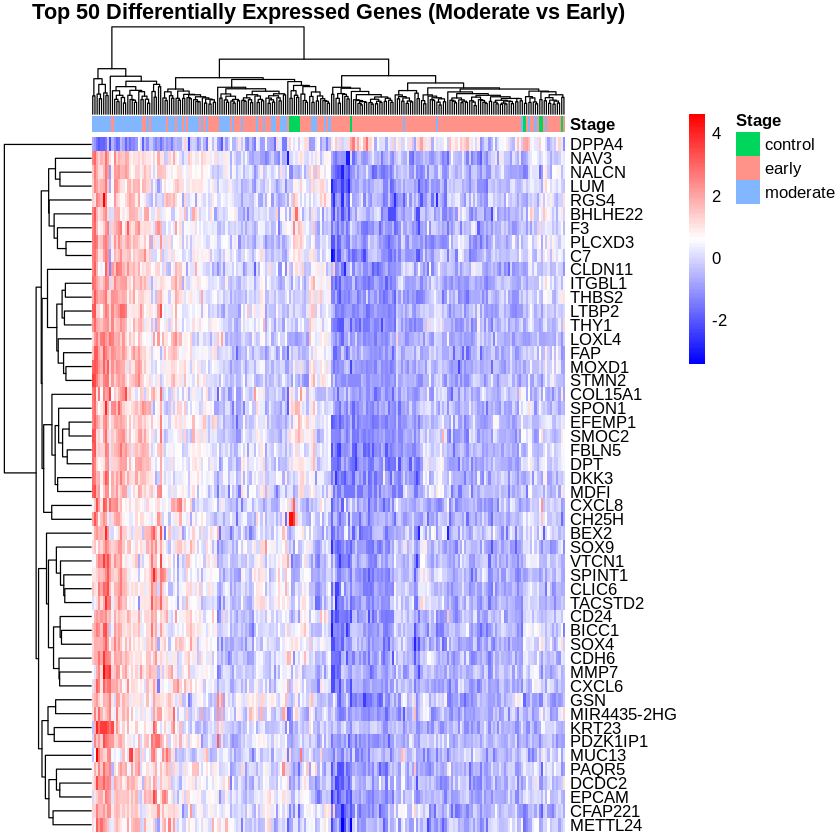

In [ ]:
## Heatmap

top_df <- results_df %>%
  filter(Significance != "Not Significant") %>%
  filter(!is.na(padj)) %>%
  arrange(padj) %>%
  head(200)

top_ids <- rownames(top_df)

# Map IDs to gene symbols
annotations <- select(
  org.Hs.eg.db,
  keys = top_ids,
  columns = c("SYMBOL"),
  keytype = "ENTREZID"
)

# Extract normalized counts
top_matrix <- assay(PCA_fig)[top_ids, ]

# Match symbols
gene_symbols <- annotations$SYMBOL[
  match(rownames(top_matrix), annotations$ENTREZID)
]

# Remove LOC + NA
valid_genes <- !is.na(gene_symbols) & !grepl("^LOC", gene_symbols)

top_matrix <- top_matrix[valid_genes, ]
gene_symbols <- gene_symbols[valid_genes]

# Remove duplicate gene symbols
non_dup <- !duplicated(gene_symbols)
top_matrix <- top_matrix[non_dup, ]
gene_symbols <- gene_symbols[non_dup]

# Top 50
top_matrix <- top_matrix[1:50, ]
gene_symbols <- gene_symbols[1:50]

# Assign gene symbols
rownames(top_matrix) <- gene_symbols


top_matrix_scaled <- t(scale(t(top_matrix)))

# Annotation
annotation_col <- data.frame(Stage = meta_data$Stage)
rownames(annotation_col) <- colnames(top_matrix_scaled)

# Heatmap
pheatmap(top_matrix_scaled,
         cluster_rows = TRUE,
         cluster_cols = TRUE,
         annotation_col = annotation_col,
         show_rownames = TRUE,
         show_colnames = FALSE,
         color = colorRampPalette(c("blue", "white", "red"))(100),
         main = "Top 50 Differentially Expressed Genes (Moderate vs Early)")

In [ ]:
## Table

top_genes_pool <- sig_genes$ENTREZID[1:200]

# Annotate
annotations <- select(
  org.Hs.eg.db,
  keys = top_genes_pool,
  columns = c("SYMBOL", "GENENAME"),
  keytype = "ENTREZID"
)

# Build table
gene_annotation_table <- data.frame(
  ENTREZID = annotations$ENTREZID,
  SYMBOL = annotations$SYMBOL,
  GENENAME = annotations$GENENAME,
  stringsAsFactors = FALSE
)

# Remove NA + LOC
gene_annotation_table <- gene_annotation_table[
  !is.na(gene_annotation_table$SYMBOL) &
  !grepl("^LOC", gene_annotation_table$SYMBOL),
]

# Remove duplicates
gene_annotation_table <- gene_annotation_table[
  !duplicated(gene_annotation_table$SYMBOL),
]

# Take top 50
gene_annotation_table <- gene_annotation_table[1:50, ]

gene_annotation_table

write.csv(gene_annotation_table, "Top50_Gene_Annotations.csv", row.names = FALSE)

'select()' returned 1:1 mapping between keys and columns



,ENTREZID,SYMBOL,GENENAME
,<chr>,<chr>,<chr>
1,9358,ITGBL1,integrin subunit beta like 1
2,4316,MMP7,matrix metallopeptidase 7
3,10516,FBLN5,fibulin 5
4,84171,LOXL4,lysyl oxidase like 4
5,89795,NAV3,neuron navigator 3
6,51473,DCDC2,doublecortin domain containing 2
7,4053,LTBP2,latent transforming growth factor beta binding protein 2
8,26002,MOXD1,monooxygenase DBH like 1
9,11075,STMN2,stathmin 2


In [ ]:
## Top 50 genes plot

# Get gene annotations
annotations <- select( org.Hs.eg.db, keys = top_genes_pool, columns = c("SYMBOL", "GENENAME"), keytype = "ENTREZID")

# Merge annotations
top_genes_df <- sig_genes[sig_genes$ENTREZID %in% top_genes_pool, ]
top_genes_df <- merge(top_genes_df, annotations, by = "ENTREZID")

# Remove LOC + NA
top_genes_df <- top_genes_df[!is.na(top_genes_df$SYMBOL) & !grepl("^LOC", top_genes_df$SYMBOL) & !is.na(top_genes_df$log2FoldChange), ]

# Remove duplicates
top_genes_df <- top_genes_df[!duplicated(top_genes_df$SYMBOL), ]

# Top 50
top_genes_df <- top_genes_df[order(top_genes_df$padj), ]
top_genes_df <- top_genes_df[1:50, ]


top_genes_df$SYMBOL <- as.character(top_genes_df$SYMBOL)
top_genes_df <- top_genes_df[order(top_genes_df$log2FoldChange), ]
top_genes_df$SYMBOL <- factor(top_genes_df$SYMBOL, levels = top_genes_df$SYMBOL)
top_genes_df$label <- top_genes_df$SYMBOL

# Plot
p <- ggplot(top_genes_df, aes(x = SYMBOL, y = log2FoldChange, fill = log2FoldChange > 0)) +
  geom_col() +
  coord_flip() +
  scale_fill_manual(
    values = c("TRUE" = "plum", "FALSE" = "palegreen3"),
    labels = c("FALSE" = "Downregulated", "TRUE" = "Upregulated")
  ) +
  geom_text(
    aes(label = label),
    hjust = ifelse(top_genes_df$log2FoldChange > 0, -0.1, 1.05),
    size = 3
  ) +
  scale_y_continuous(expand = expansion(mult = c(0.1, 0.2))) +
  theme_minimal(base_size = 14) +
  theme(
    plot.title = element_text(hjust = 0.5)
  ) +
  labs(
    title = "Top 50 Differentially Expressed Genes (Moderate vs Early Fibrosis)",
    x = "Gene Symbol",
    y = "Log2 Fold Change",
    fill = "Direction"
  )

# Save figure
ggsave("top50_genes_plot.png", plot = p, width = 14, height = 10, units = "in", dpi = 300)

'select()' returned 1:1 mapping between keys and columns



In [ ]:
## Upregulated genes

# Keep upregulated genes
up_pool <- results_df[results_df$log2FoldChange > 0, ]

# Rank high - low
up_pool <- up_pool[order(-up_pool$log2FoldChange), ]

top_up_pool <- head(up_pool, 200)

# Annotate
up_annotations <- select(
  org.Hs.eg.db,
  keys = top_up_pool$ENTREZID,
  columns = c("SYMBOL", "GENENAME"),
  keytype = "ENTREZID"
)

# Merge
top50_up_df <- merge(top_up_pool, up_annotations, by = "ENTREZID")

# Remove LOC + NA
top50_up_df <- top50_up_df[
  !is.na(top50_up_df$SYMBOL) &
  !grepl("^LOC", top50_up_df$SYMBOL),
]

# Remove duplicates
top50_up_df <- top50_up_df[
  !duplicated(top50_up_df$SYMBOL),
]

# Top 50
top50_up_df <- top50_up_df[1:50, ]

# Order
top50_up_df$SYMBOL <- factor(
  top50_up_df$SYMBOL,
  levels = rev(top50_up_df$SYMBOL)
)

# Plot
p_up <- ggplot(top50_up_df, aes(x = SYMBOL, y = log2FoldChange)) +
  geom_col(fill = "plum") +
  coord_flip() +
  theme_minimal(base_size = 14) +
  theme(plot.title = element_text(hjust = 0.5)) +
  labs(
    title = "Top 50 Upregulated Genes (Moderate vs Early Fibrosis)",
    x = "Gene Symbol",
    y = "Log2 Fold Change"
  )

# Save plot
ggsave("top50_upregulated.png", p_up, width = 12, height = 10, dpi = 300)

'select()' returned 1:1 mapping between keys and columns



In [ ]:
## TOP 50 DOWNREGULATED

# Keep downregulated genes
down_pool <- results_df[results_df$log2FoldChange < 0, ]

# Rank by high - low
down_pool <- down_pool[order(down_pool$log2FoldChange), ]

top_down_pool <- head(down_pool, 200)

# Annotate
down_annotations <- select(
  org.Hs.eg.db,
  keys = top_down_pool$ENTREZID,
  columns = c("SYMBOL", "GENENAME"),
  keytype = "ENTREZID"
)

# Merge
top50_down_df <- merge(top_down_pool, down_annotations, by = "ENTREZID")

# Remove LOC + NA
top50_down_df <- top50_down_df[
  !is.na(top50_down_df$SYMBOL) &
  !grepl("^LOC", top50_down_df$SYMBOL),
]

# Remove duplicates
top50_down_df <- top50_down_df[
  !duplicated(top50_down_df$SYMBOL),
]

# Top 50
top50_down_df <- top50_down_df[1:50, ]

# Order
top50_down_df$SYMBOL <- factor(
  top50_down_df$SYMBOL,
  levels = rev(top50_down_df$SYMBOL)
)

# Plot
p_down <- ggplot(top50_down_df, aes(x = SYMBOL, y = log2FoldChange)) +
  geom_col(fill = "palegreen3") +
  coord_flip() +
  theme_minimal(base_size = 14) +
  theme(plot.title = element_text(hjust = 0.5)) +
  labs(
    title = "Top 50 Downregulated Genes (Moderate vs Early Fibrosis)",
    x = "Gene Symbol",
    y = "Log2 Fold Change"
  )

# Save plot
ggsave("top50_downregulated.png", p_down, width = 12, height = 10, dpi = 300)

'select()' returned 1:1 mapping between keys and columns



In [ ]:
# Map to gene symbols
annotations_all <- select( org.Hs.eg.db, keys = sig_genes$ENTREZID, columns = "SYMBOL", keytype = "ENTREZID")

sig_annotated <- merge(sig_genes, annotations_all, by = "ENTREZID")

# Remove LOC + NA
sig_annotated <- sig_annotated[ !is.na(sig_annotated$SYMBOL) & !grepl("^LOC", sig_annotated$SYMBOL), ]

# Define gene lists
up_genes <- sig_annotated$ENTREZID[ sig_annotated$log2FoldChange > 1 ]

down_genes <- sig_annotated$ENTREZID[ sig_annotated$log2FoldChange < -1 ]

# Clean lists
up_genes <- unique(up_genes)
down_genes <- unique(down_genes)

'select()' returned 1:1 mapping between keys and columns



In [ ]:
# Pathway Analysis
ego_up <- enrichGO(gene = up_genes, OrgDb = org.Hs.eg.db, keyType = "ENTREZID", ont = "BP", pAdjustMethod = "BH", pvalueCutoff = 0.05, qvalueCutoff = 0.2, readable = TRUE)

ego_down <- enrichGO(gene = down_genes, OrgDb = org.Hs.eg.db, keyType = "ENTREZID", ont = "BP", pAdjustMethod = "BH", pvalueCutoff = 0.05, qvalueCutoff = 0.2, readable = TRUE)

Warning message in (function (model, data, ...) :
“Arguments in `...` must be used.
✖ Problematic argument:
• by = "Count"
ℹ Did you misspell an argument name?”
Warning message in (function (model, data, ...) :
“Arguments in `...` must be used.
✖ Problematic argument:
• by = "Count"
ℹ Did you misspell an argument name?”


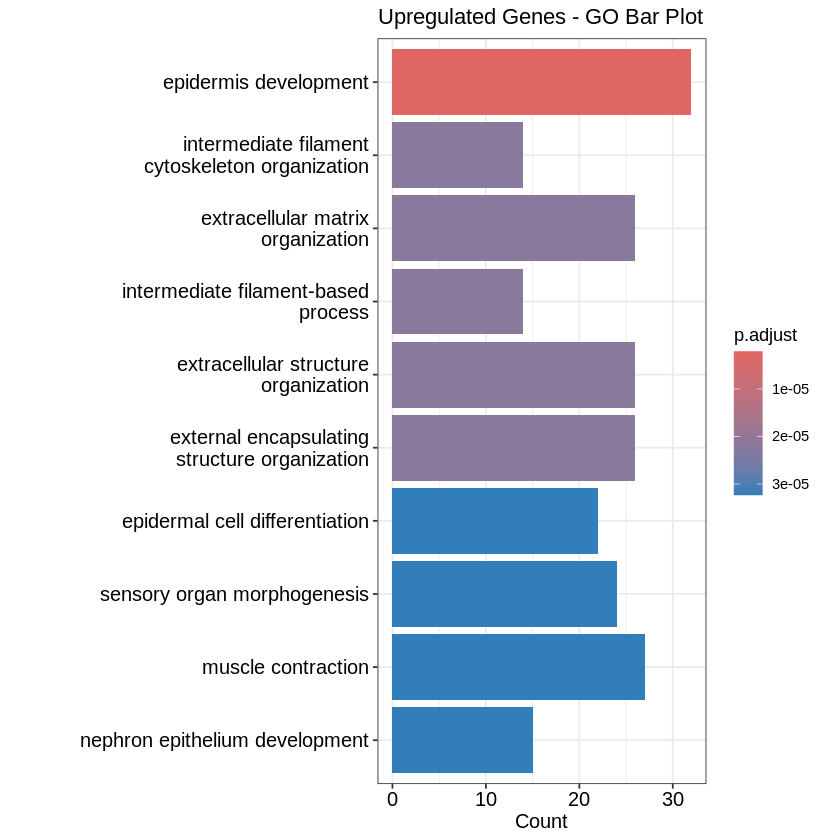

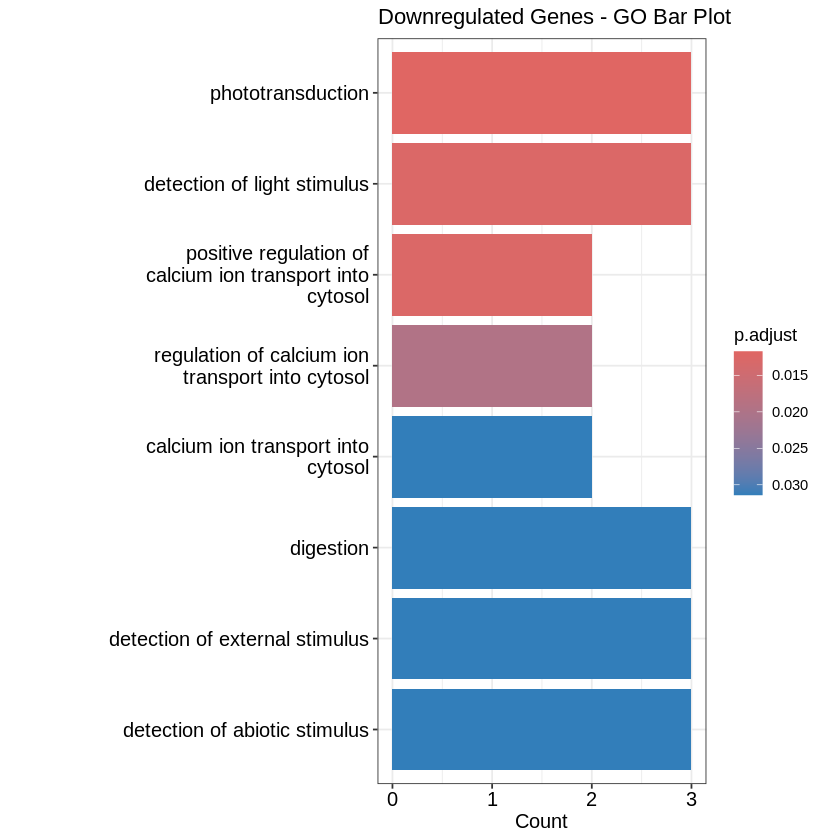

In [ ]:
# Bar plot for top 10 enriched pathways
barplot(ego_up, showCategory = 10, title = "Upregulated Genes - GO Bar Plot")
barplot(ego_down, showCategory = 10, title = "Downregulated Genes - GO Bar Plot")

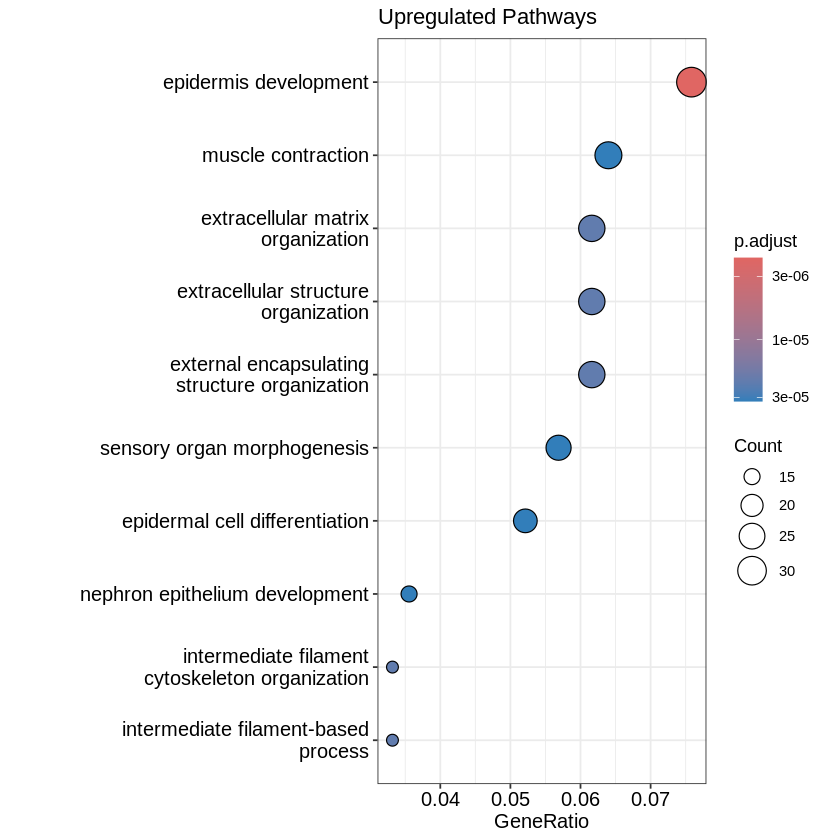

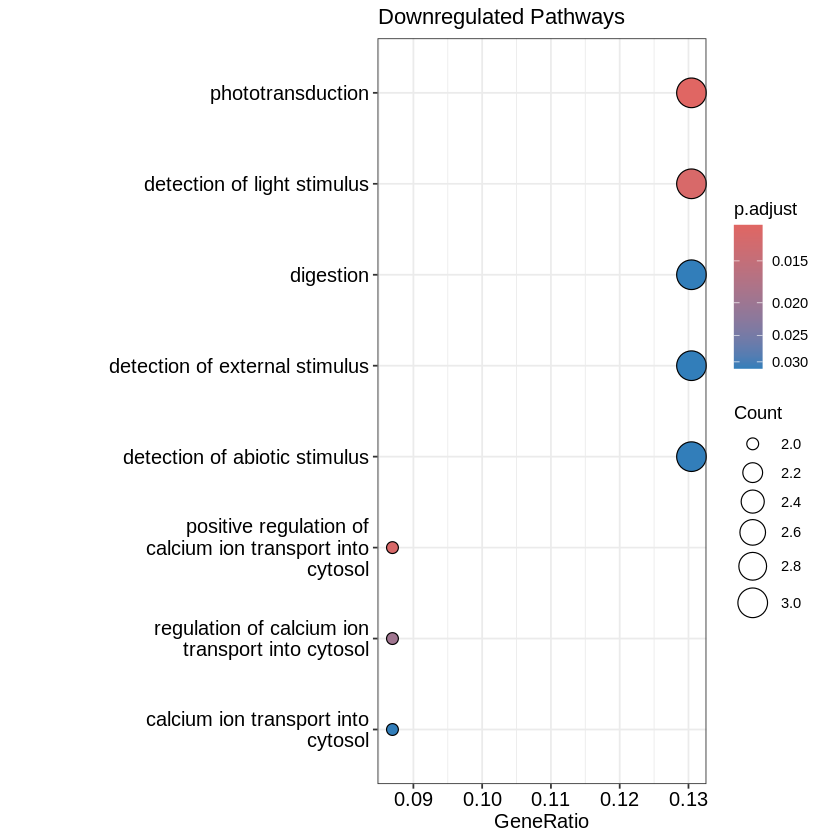

In [ ]:
dotplot(ego_up, showCategory = 10) + ggtitle("Upregulated Pathways")

dotplot(ego_down, showCategory = 10) + ggtitle("Downregulated Pathways")